In [428]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from utils.data_utils import TitanicDataHelper
import warnings
warnings.filterwarnings("ignore")

## Data Visualization

In [429]:
x_train, x_test, y_train, y_test = TitanicDataHelper.load_dataset(normalize=False)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((712, 8), (179, 8), (712,), (179,))

In [430]:
x_train.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
709,3,28.0,1,1,15.2458,1,0,0
439,2,31.0,0,0,10.5000,1,0,1
840,3,20.0,0,0,7.9250,1,0,1
720,2,6.0,0,1,33.0000,0,0,1
39,3,14.0,1,0,11.2417,0,0,0


In [431]:
y_train.head()

709    1
439    0
840    0
720    1
39     1
Name: Survived, dtype: int64

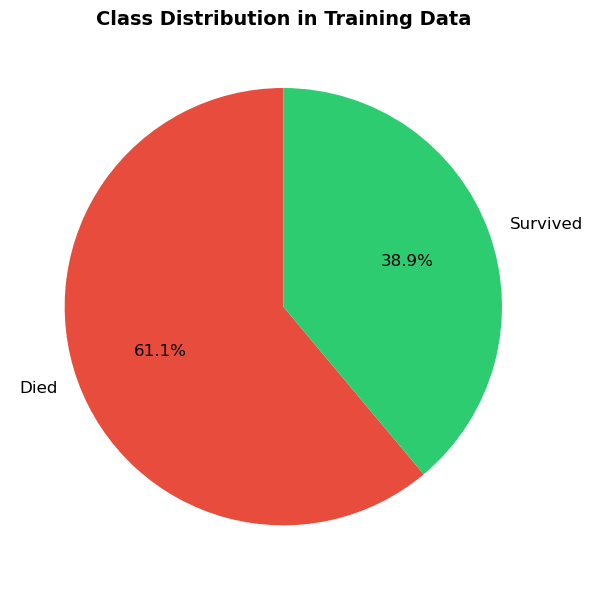

Died: 435 (61.1%)
Survived: 277 (38.9%)


In [432]:
TitanicDataHelper.plot_outcome_distribution(x_train, y_train)

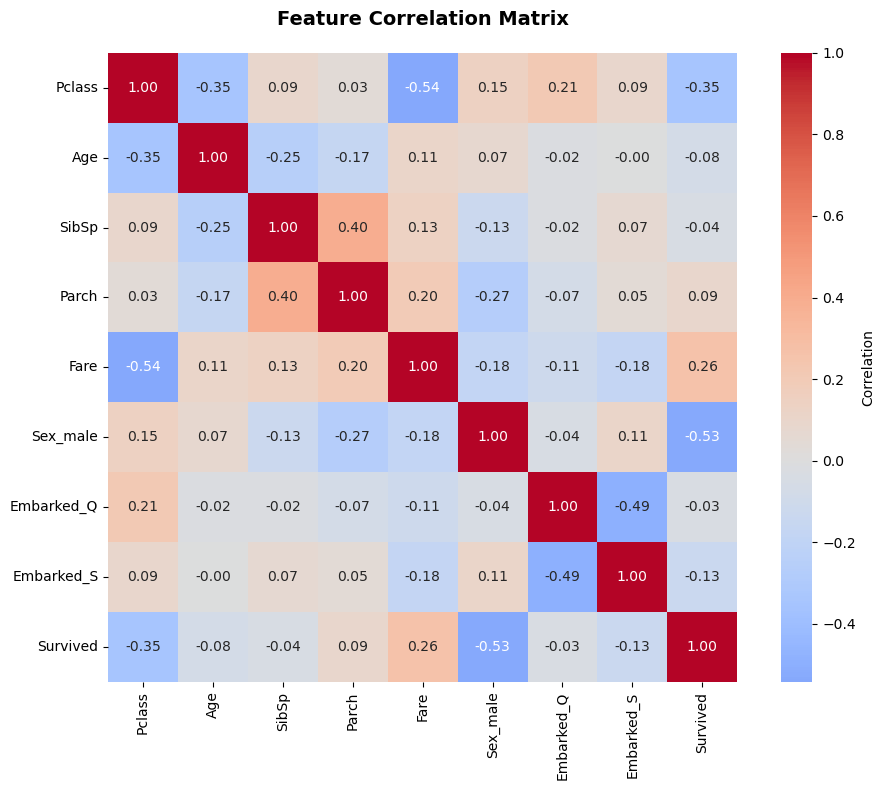

In [433]:
TitanicDataHelper.plot_correlation(x_train, y_train)

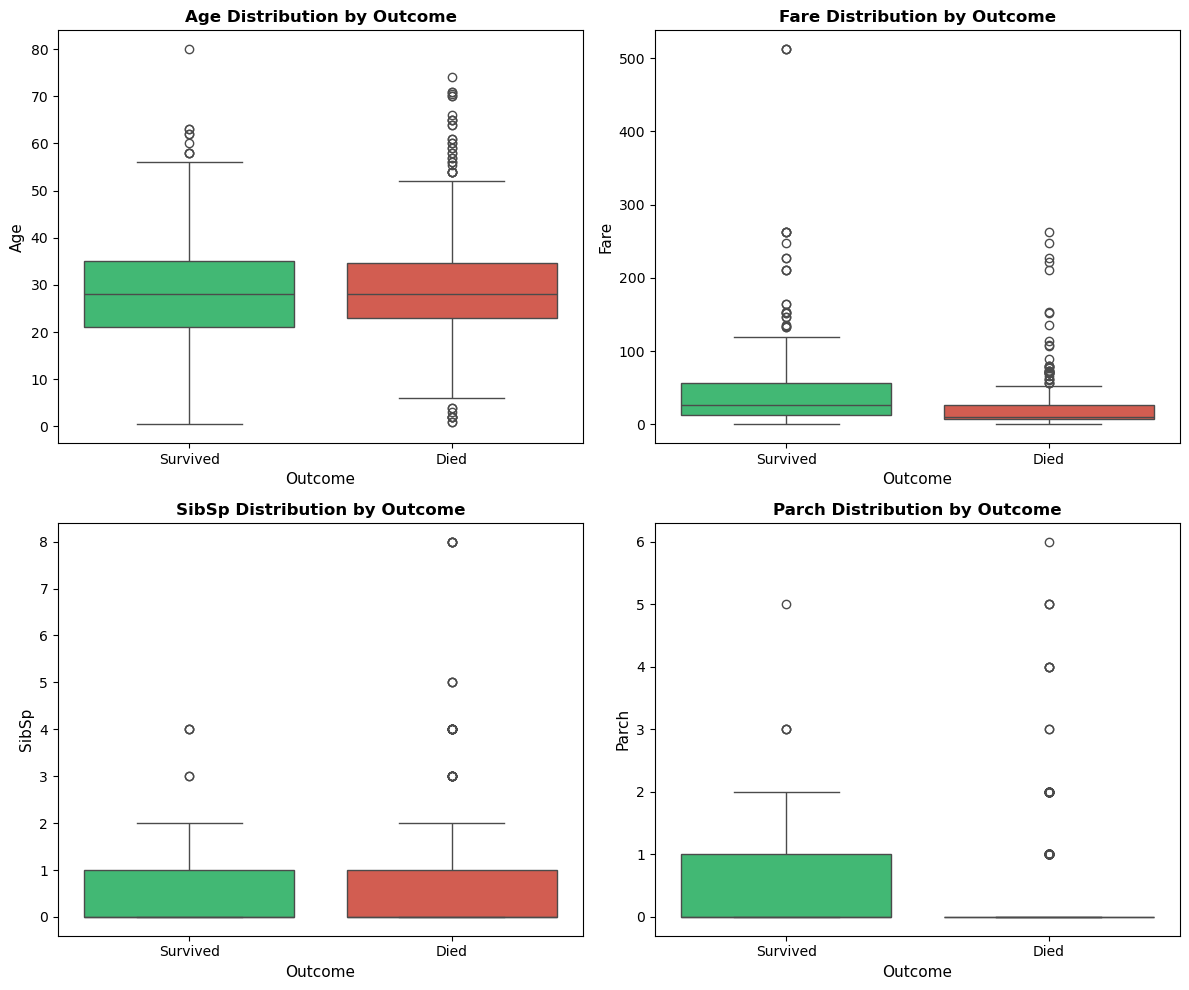

In [434]:
TitanicDataHelper.plot_boxplots(x_train, y_train)

## Model Training

In [435]:
x_survived = x_train[y_train == 1]
x_died = x_train[y_train == 0]

In [436]:
class Node:
    def __init__(self, feature=None, threshold=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.value = value
        self.left = None
        self.right = None

    def append_left(self, node):
        self.left = node
    
    def append_right(self, node):
        self.right = node
    
    def split_left_right(self, data):
        left_data = data[data[self.feature] <= self.threshold]
        right_data = data[data[self.feature] > self.threshold]
        return left_data, right_data

In [437]:
def compute_impurity(data):
    if len(data) == 0:
        return 0
    
    survived_prob = data["Survived"].mean()
    died_prob = 1 - survived_prob
    
    prob_sum = survived_prob ** 2 + died_prob ** 2
    return 1 - prob_sum

In [438]:
def find_best_split(data, thresholds_size=20):
    prior_impurity = compute_impurity(data)
    splits = []
    
    features = data.drop(columns=["Survived"]).columns
    chosen_features = np.random.choice(features, size=int(np.sqrt(len(features))), replace=False)
    
    for feature in chosen_features:
        thresholds = np.linspace(start=data[feature].min(), stop=data[feature].max(), num=thresholds_size)
        
        for threshold in thresholds:
            left_data = data[data[feature] <= threshold]
            right_data = data[data[feature] > threshold]
            
            if len(left_data) == 0 or len(right_data) == 0:
                continue
            
            left_impurity = compute_impurity(left_data)
            right_impurity = compute_impurity(right_data)
            
            weighted_left_impurity = (len(left_data) / len(data)) * left_impurity
            weighted_right_impurity = (len(right_data) / len(data)) * right_impurity
            
            weighted_impurity = weighted_left_impurity + weighted_right_impurity
            gain = prior_impurity - weighted_impurity
            
            splits.append({"gain": gain, "feature": feature, "threshold": threshold})
            
    if not splits:
        return {"gain": 0, "feature": None, "threshold": None}
    
    best_split = max(splits, key=lambda x: x['gain'])
    return best_split
        

In [439]:
def build_tree(data, max_depth=10, depth=0):
    if depth >= max_depth or len(data) <= 1:
        if len(data) == 0:
            prob = 0
        else:
            prob = data["Survived"].mean()
        return Node(value=prob)
    
    best_split = find_best_split(data)
    if best_split["gain"] <= 0 or best_split["feature"] is None:
        prob = data["Survived"].mean()
        return Node(value=prob)
    
    node = Node(best_split["feature"], best_split["threshold"])
    left_data, right_data = node.split_left_right(data)
    
    node.left = build_tree(left_data, max_depth, depth + 1)
    node.right = build_tree(right_data, max_depth, depth + 1)
    
    return node

In [440]:
def build_forest(forest_size=10, sample_size=50, max_tree_depth=10):
    x_train_labelled = x_train.copy()
    x_train_labelled["Survived"] = y_train
    
    forest = []
    
    for i in range(forest_size):
        x_tree_sample =  x_train_labelled.sample(n=sample_size, replace=True)
        tree = build_tree(x_tree_sample, max_tree_depth)
        forest.append(tree)
        
        if (i + 1) % 10 == 0:
            print(f"Built {i + 1}/{forest_size} trees")

    return forest

In [441]:
forest = build_forest(forest_size=50, sample_size=int(0.8 * len(x_train)), max_tree_depth=4)

Built 10/50 trees
Built 20/50 trees
Built 30/50 trees
Built 40/50 trees
Built 50/50 trees


In [442]:
def predict(node, x):
    if node.value is not None:
        return node.value >= 0.5, node.value
    if x[node.feature] <= node.threshold:
        return predict(node.left, x)
    else:
        return predict(node.right, x)

## Model Evaluation

In [443]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc

In [444]:
predictions = []
probabilities = []

for idx, x in x_test.iterrows():
    forest_predictions = []
    forest_probabilities = []
    
    for tree in forest:
        prediction, prob = predict(tree, x)
        forest_predictions.append(prediction)
        forest_probabilities.append(prob)
    
    forest_predictions = np.array(forest_predictions)
    forest_probabilities = np.array(forest_probabilities)
    
    classes, counts = np.unique(forest_predictions, return_counts=True)
    class_mode_idx = np.argmax(counts)
    
    predictions.append(classes[class_mode_idx])
    probabilities.append(forest_probabilities.mean())

predictions = np.array(predictions)
probabilities = np.array(probabilities)

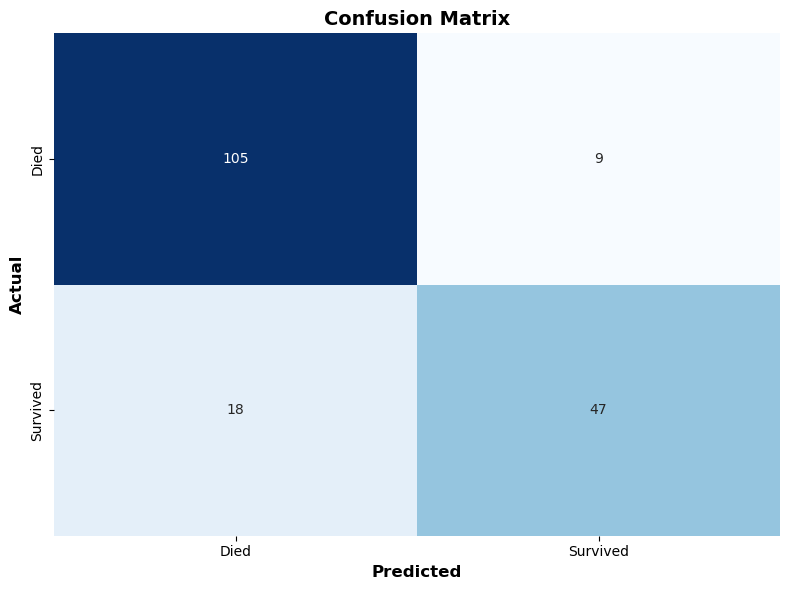

True Negatives: 105
False Positives: 9
False Negatives: 18
True Positives: 47

Sensitivity (Recall): 0.7231
Specificity: 0.9211
Precision: 0.8393
Accuracy: 0.8492
F1 Score: 0.7769


In [445]:
cm = confusion_matrix(y_test, predictions)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
            xticklabels=["Died", "Survived"], yticklabels=["Died", "Survived"])
ax.set_xlabel("Predicted", fontsize=12, fontweight="bold")
ax.set_ylabel("Actual", fontsize=12, fontweight="bold")
ax.set_title("Confusion Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

tn_val, fp_val, fn_val, tp_val = cm.ravel()
sensitivity = tp_val / (tp_val + fn_val)
specificity = tn_val / (tn_val + fp_val)
precision = tp_val / (tp_val + fp_val)
accuracy = (tp_val + tn_val) / (tp_val + tn_val + fp_val + fn_val)
f1_score = 2 * ((precision * sensitivity) / (precision + sensitivity))

print(f"True Negatives: {tn_val}")
print(f"False Positives: {fp_val}")
print(f"False Negatives: {fn_val}")
print(f"True Positives: {tp_val}")
print(f"\nSensitivity (Recall): {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1_score:.4f}")

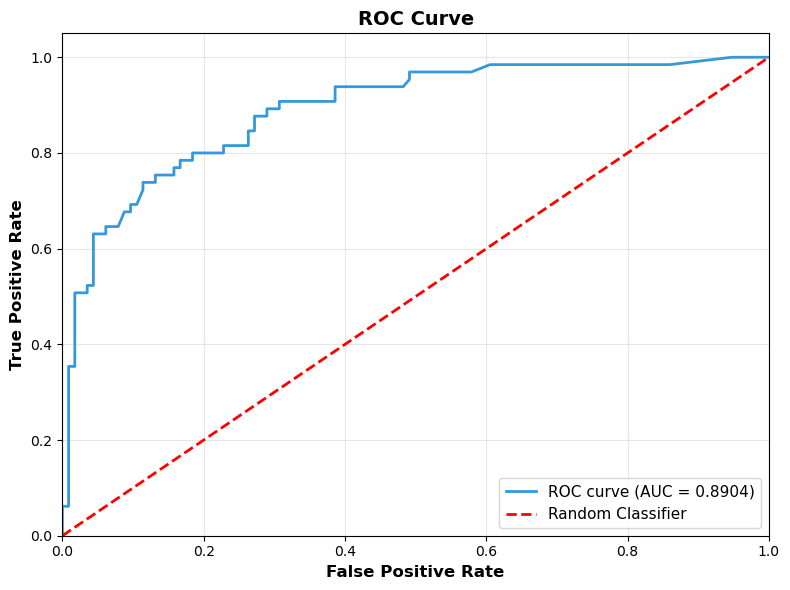

Area Under the Curve (AUC): 0.8904


In [446]:
fpr, tpr, thresholds = roc_curve(y_test, probabilities)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color="#3498db", lw=2, label=f"ROC curve (AUC = {roc_auc:.4f})")
ax.plot([0, 1], [0, 1], color="red", lw=2, linestyle="--", label="Random Classifier")
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel("False Positive Rate", fontsize=12, fontweight="bold")
ax.set_ylabel("True Positive Rate", fontsize=12, fontweight="bold")
ax.set_title("ROC Curve", fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Area Under the Curve (AUC): {roc_auc:.4f}")